In [4]:
import numpy as np
import matplotlib.pyplot as plt

## Ejercicio 12

El instituto de investigaciones de enfermedades de Macondo descubre que con el paso del tiempo las personas recuperadas pierden inmunidad y vuelven a ser susceptibles luego de un tiempo promedio $\omega^{-1}$.

$$
\frac{dS}{dt} = -\beta \frac{SI}{N} + \omega R
$$

$$
\frac{dE}{dt} = \beta \frac{SI}{N} - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I - \omega R
$$

**(a)** Discutir de qué forma deberían evolucionar las poblaciones de cada compartimento en este caso.

**(b)** Repetir la simulación considerando un tiempo medio de inmunidad de $180$ días.

**(c)** Graficar la evolución temporal de las poblaciones de cada compartimento y el diagrama de fase de $I$ y $S$.

**(d)** Verificar que la población de la ciudad se mantiene constante a lo largo de la simulación.

**(e)** Medir el período de las oscilaciones (intervalo inter-epidémico $T_E$).

**(f)** ¿A qué valores tienden las poblaciones (en porcentaje) cuando el tiempo $t$ tiende a infinito? (equilibrio endémico)

In [5]:
# Ejercio 12

# S(t): personas susceptibles
# E(t): personas expuestas
# I(t): personas infectadas
# R(t): personas recuperadas

# beta: tasa transmisión
# gamma: tasa recuperación
# sigma: tasa encubación
# omega: tiempo pérdida inmune

def sistema(t,estado, beta, gamma, sigma, omega, N):
    s, e, i, r = estado

    dSdt = -beta * (s*i)/N + omega * r
    dEdt = beta * (s*i)/N - sigma * e
    dIdt = sigma * e - gamma * i - omega * r
    dRdt = gamma * i

    return np.array([dSdt, dEdt, dIdt, dRdt])

def euler(N, s0, e0, i0, r0, beta, gamma, sigma, omega, t0, tf, h):
    t_valores = [t0]
    s_valores = [s0]
    e_valores = [e0]
    i_valores = [i0]
    r_valores = [r0]

    t, s, e, i, r = t0, s0, e0, i0, r0

    while t < tf:
        estado = np.array([s, e, i, r])
        pendiente = sistema(t, estado, beta, gamma, sigma, omega, N)

        estado = estado + h * pendiente
        s, e, i, r = estado

        t = t + h

        t_valores.append(t)
        s_valores.append(s)
        e_valores.append(e)
        i_valores.append(i)
        r_valores.append(r)

    return np.array(t_valores), np.array(s_valores), np.array(e_valores), np.array(i_valores), np.array(r_valores)




C:\Users\dowhy\AppData\Local\Temp\ipykernel_21912\3317499304.py:16: RuntimeWarning: overflow encountered in scalar multiply
  dSdt = -beta * (s*i)/N + omega * r
C:\Users\dowhy\AppData\Local\Temp\ipykernel_21912\3317499304.py:17: RuntimeWarning: overflow encountered in scalar multiply
  dEdt = beta * (s*i)/N - sigma * e
C:\Users\dowhy\AppData\Local\Temp\ipykernel_21912\3317499304.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  dEdt = beta * (s*i)/N - sigma * e


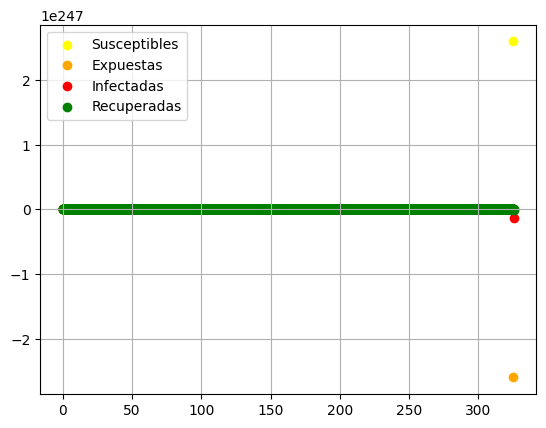

In [6]:
# Simular con tiempo medi de inmunidad de 180 dias: omega=1/180

tiempos, susceptibles, expuestas, infectadas, recuperadas = euler(45000000, 44999999, 0, 10, 0, 0.2, 0.1, 0.5, 1/180, 0, 2200, 0.1)

plt.scatter(tiempos, susceptibles, label='Susceptibles', color='yellow')
plt.scatter(tiempos, expuestas, label='Expuestas', color='orange')
plt.scatter(tiempos, infectadas, label='Infectadas', color='red')
plt.scatter(tiempos, recuperadas, label='Recuperadas', color='green')

plt.legend()
plt.grid(True)
plt.show()
